# POWER SPECTRUM EXAMPLE

In [1]:
import numpy as np
import numpy.fft as fft
import pylab as plt
import pyccl as ccl
#plt.rcParams["figure.figsize"] = (14,7)
import fastbox
from fastbox.box import CosmoBox, default_cosmo
from fastbox.foregrounds import ForegroundModel
import fastbox.power as power

#from power import *
import time, sys


## GENERATE DENSITY FIELD

In [2]:
box = CosmoBox(cosmo=default_cosmo, box_scale=(1e3,1e3,1e3), nsamp=64, 
               redshift=0.8, realise_now=False)
_ = box.realise_density()

 /home/bruno/anaconda3/envs/fast-test/lib/python3.8/site-packages/pyccl/pk2d.py:207: RuntimeWarning:divide by zero encountered in log


## HI TRACER

In [3]:
tracer = fastbox.tracers.HITracer(box)
delta_hi = box.delta_x * tracer.bias_HI()

delta_hi_ln = box.lognormal(delta_hi)
hi_cube = tracer.signal_amplitude() * (1. + delta_hi_ln)

## GENERATE GALAXY CATALOG

In [4]:
# Initialise the Galaxy Tracer
mean_density = 1e-3 # galaxies per Mpc^3
bias_g = 1.5

delta_g = box.delta_x * bias_g

delta_g_ln = box.lognormal(delta_g)

mean_density = 1e-3
gal_tracer = fastbox.tracers.GalaxyTracer(box=box, vol_density=mean_density, bias=bias_g)

galaxy_coordinates = gal_tracer.generate_catalogue(delta_g_ln)

print(f"Generated {len(galaxy_coordinates)} galaxies.")

mesh_g = gal_tracer._assign_cic(galaxy_coordinates,overdensity=True)

Generated 999161 galaxies.


## POWER SPECTRUM 

In [5]:
# INITIALIZE POWER OBJECT
power = power.Power(box)

### estimate power spectrum

In [6]:
k, pk_g, _ = power.unweighted_power(mesh_g)
k, pk_hi, _ = power.unweighted_power(hi_cube)
k, pk_X, _ = power.unweighted_power(hi_cube, mesh_g)

Calculating auto-correlation power spectrum...
DONE
Calculating auto-correlation power spectrum...
DONE
Calculating cross-correlation power spectrum
DONE


### Calculate theoretical predictions

In [7]:
km,pkm = power.matter_power_spectrum(k,rsd=False,sigma_nl=0)

k, pk_hi_obs, std_hi_obs = power.model_obs_power_IM(k, 
                                                    pkm, 
                                                    bias=tracer.bias_HI(),
                                                    Tb = tracer.signal_amplitude(),
                                                    sigdeg=0, 
                                                    rsd = False,
                                                    sigma_nl=0)

k, pk_gal_obs, std_gal_obs = power.model_obs_power_gal(k, 
                                                       pkm, 
                                                       bias=bias_g,
                                                       MAS='CIC', 
                                                       rsd = False,
                                                       sigma_nl=0)
k, pk_X_obs, std_X_obs = power.model_obs_power_CC(k, 
                                                  pkm, 
                                                  bias_HI=tracer.bias_HI(),
                                                  bias_gal = bias_g,
                                                  Tb = tracer.signal_amplitude(),
                                                  sigdeg=0,
                                                  MAS = 'CIC',
                                                  rsd = False,
                                                  sigma_nl=0)

DONE
DONE
DONE


### plotting

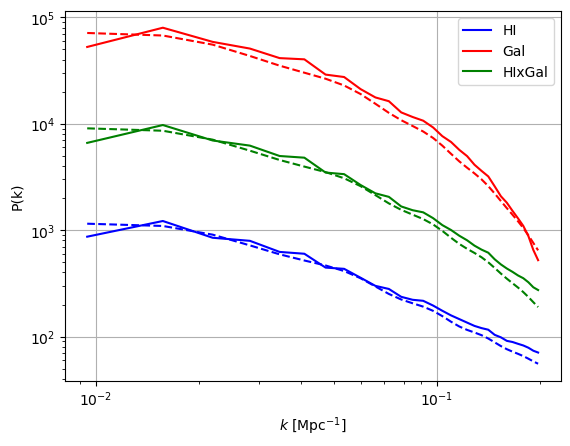

In [11]:
plt.plot(k, pk_hi, label='HI',color='b')
plt.plot(k, pk_hi_obs,linestyle='--',color='b')
plt.plot(k, pk_g-1/mean_density, label='Gal', color='r')
plt.plot(k, pk_gal_obs, linestyle='--',color='r')
plt.plot(k, pk_X, label='HIxGal',color='g')
plt.plot(k, pk_X_obs,linestyle='--',color='g')
plt.loglog()
plt.legend()
plt.grid()
plt.ylabel('P(k)')
plt.xlabel(r'$k \ [\mathrm{Mpc}^{-1}]$')
plt.show()

We can omit aliasing, grid correction, and channelization from the forward model because they represent physical or observational effects that simply do not occur in your specific simulation architecture. First, aliasing is unnecessary because our mock generates the linear density field directly on the finite Fourier grid; this naturally band-limits the signal, meaning no theoretical power is generated beyond the Nyquist frequency to fold back into the box. Second, the grid correction (voxel window function) is unneeded because the simulation point-samples the field exactly at cell centers rather than volume-averaging the continuous field, meaning no top-hat suppression takes place. Finally, channelization damping is not required because our cube is natively generated on a discrete 3D spatial grid—including the line-of-sight $z$-direction—from the start, rather than being built from continuous frequency observations that must be integrated into discrete channels.